In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("2016-2025_Kdramas_dataset.csv")

print(df.head())

                             title  release_year  episodes  ratings netflix  \
0         Fantastic (Korean Drama)        2016.0      16.0      7.6      no   
1                     Dr. Romantic        2016.0      20.0      8.7     yes   
2  Weightlifting Fairy Kim Bok-joo        2016.0      16.0      8.7     yes   
3                 Still Loving You        2016.0     125.0      7.6      no   
4           Monster (Drama Series)        2016.0      50.0      7.2      no   

   viu prime_video disney_plus  
0   no          no          no  
1  yes         yes          no  
2  yes         yes          no  
3   no          no          no  
4   no          no          no  


In [ ]:
df = df.dropna()

In [ ]:
label_encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

In [ ]:
X = df.drop("netflix", axis=1)
y = df["netflix"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#For Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 68.57142857142857 %


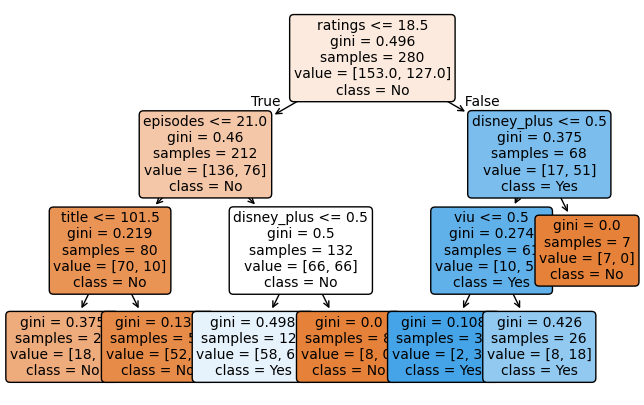

In [ ]:
#For Decision Tree Visualization

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(8,5))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

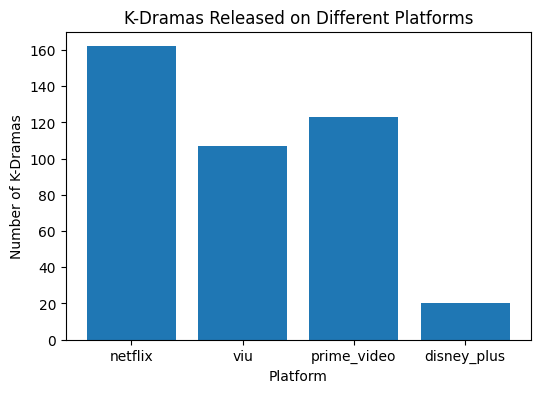

In [ ]:
import matplotlib.pyplot as plt

platforms = ['netflix', 'viu', 'prime_video', 'disney_plus']
counts = df[platforms].sum()

plt.figure(figsize=(6,4))

plt.bar(platforms, counts)

plt.title("K-Dramas Released on Different Platforms")
plt.xlabel("Platform")
plt.ylabel("Number of K-Dramas")

plt.show()

In [ ]:
#For K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)



KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 58.57142857142858 %


In [ ]:
#For Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = nb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 54.285714285714285 %
